
# Credit Card Spending Analysis in India

# Importing of Libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Configure visualization settings

In [14]:
plt.style.use("default")
sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


# File Path Configuration

# Update path to match my local file location

In [15]:
file_path = Path(
    r"C:\Users\USER\Downloads\BIGFARMER DATABASE\Datasets!\Credit Card Spending in India.csv"
)

print(f"File path set to: {file_path}")

File path set to: C:\Users\USER\Downloads\BIGFARMER DATABASE\Datasets!\Credit Card Spending in India.csv


# Data Loading Function

In [16]:
def load_credit_card_data(file_path: Path):
    """
    Loads the credit card dataset using multiple encoding
    and delimiter attempts for maximum compatibility.
    """
    if not file_path.exists():
        print(f"❌ File not found: {file_path}")
        print(f"Working directory: {os.getcwd()}")
        return None

    encodings = ["utf-8", "latin1", "iso-8859-1", "cp1252"]
    separators = [",", ";", "\t"]

    for encoding in encodings:
        for sep in separators:
            try:
                df = pd.read_csv(file_path, encoding=encoding, sep=sep)
                print(f"✅ Loaded using encoding='{encoding}', separator='{sep}'")
                print(f"Dataset shape: {df.shape}")
                return df
            except (UnicodeDecodeError, pd.errors.ParserError):
                continue

    print("❌ Failed to load dataset with available encodings.")
    return None

# Data Load

In [17]:
df = load_credit_card_data(file_path)
if df is None:
    raise SystemExit("Dataset loading failed.")

print("\n✅ Data loaded successfully")
print(f"Dataset Size: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Loaded using encoding='utf-8', separator=','
Dataset shape: (101, 7)

✅ Data loaded successfully
Dataset Size: 101 rows × 7 columns


# Initial Data Exploration

In [18]:
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)

print("\n📋 First 5 rows:")
display(df.head())

print("\n📋 Last 5 rows:")
display(df.tail())

print("\n📊 Dataset Info:")
df.info()

print("\n🔍 Missing Values per Column:")
print(df.isnull().sum())

print("\n📈 Descriptive Statistics:")
display(df.describe())

DATA OVERVIEW

📋 First 5 rows:


,index,City,Date,Card Type,Exp Type,Gender,Amount
0,0,"Delhi, India",10/29/2014,Gold,Bills,F,82475
1,1,"Greater Mumbai, India",8/22/2014,Platinum,Bills,F,32555
2,2,"Bengaluru, India",8/27/2014,Silver,Bills,F,101738
3,3,"Greater Mumbai, India",4/12/2014,Signature,Bills,F,123424
4,4,"Bengaluru, India",5/5/2015,Gold,Bills,F,171574



📋 Last 5 rows:


,index,City,Date,Card Type,Exp Type,Gender,Amount
96,96,"Bengaluru, India",11/1/2013,Gold,Bills,F,896384
97,97,"Delhi, India",12/7/2013,Signature,Bills,F,712001
98,98,"Greater Mumbai, India",8/5/2014,Silver,Bills,F,246865
99,99,"Greater Mumbai, India",1/8/2015,Signature,Bills,F,858729
100,100,"Delhi, India",4/11/2015,Platinum,Bills,F,581882



📊 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   index      101 non-null    int64
 1   City       101 non-null    str  
 2   Date       101 non-null    str  
 3   Card Type  101 non-null    str  
 4   Exp Type   101 non-null    str  
 5   Gender     101 non-null    str  
 6   Amount     101 non-null    int64
dtypes: int64(2), str(5)
memory usage: 5.7 KB

🔍 Missing Values per Column:
index        0
City         0
Date         0
Card Type    0
Exp Type     0
Gender       0
Amount       0
dtype: int64

📈 Descriptive Statistics:


,index,Amount
count,101.000000,101.000000
mean,50.000000,517599.831683
std,29.300171,261440.499890
min,0.000000,19226.000000
25%,25.000000,302834.000000
50%,50.000000,525977.000000
75%,75.000000,722587.000000
max,100.000000,998077.000000


# Data Preprocessing

In [19]:
print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# Standardize column names
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
print("Standardized Columns:", df.columns.tolist())

# Detect key columns programmatically
date_columns = [c for c in df.columns if "date" in c]
amount_columns = [c for c in df.columns if "amount" in c or "spend" in c]

date_col = date_columns[0] if date_columns else None
amount_col = amount_columns[0] if amount_columns else None

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    print(f"✔ Converted '{date_col}' to datetime")

if amount_col:
    df[amount_col] = pd.to_numeric(df[amount_col], errors="coerce")
    print(f"✔ Converted '{amount_col}' to numeric")

# Remove incomplete records
critical_cols = [c for c in [date_col, amount_col] if c]
df_clean = df.dropna(subset=critical_cols)

print(f"✔ Removed {df.shape[0] - df_clean.shape[0]} incomplete records")
print(f"✅ Clean dataset shape: {df_clean.shape}")

DATA PREPROCESSING
Standardized Columns: ['index', 'city', 'date', 'card_type', 'exp_type', 'gender', 'amount']
✔ Converted 'date' to datetime
✔ Converted 'amount' to numeric
✔ Removed 0 incomplete records
✅ Clean dataset shape: (101, 7)


# Analysis Functions - City Spending

In [22]:
def analyze_monthly_trends(df, date_col, amount_col):
    """Examines temporal spending trends with a 4-panel visual dashboard."""
    
    # Prepare temporal features
    df_temp = df.copy()
    df_temp['month_name'] = df_temp[date_col].dt.month_name()
    df_temp['month_num'] = df_temp[date_col].dt.month
    
    # Resample for time-series
    monthly_series = df_temp.set_index(date_col).resample("M")[amount_col].sum()
    
    # Calculate seasonality (Average spend per month name)
    seasonality = df_temp.groupby(['month_num', 'month_name'])[amount_col].sum().reset_index()

    print("\n📅 Monthly Spending Statistics:")
    print(f"Average: ₹{monthly_series.mean():,.2f}")
    print(f"Peak Month: {monthly_series.idxmax().strftime('%B %Y')} (₹{monthly_series.max():,.2f})")
    print(f"Total Period Spend: ₹{monthly_series.sum():,.2f}")

    # --- VISUALIZATION UPGRADE ---
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    plt.subplots_adjust(hspace=0.4)

    # 1. Trend Line (The 'Pulse' of spending)
    axes[0, 0].plot(monthly_series.index, monthly_series.values, 
                  marker="o", color='#2c3e50', linewidth=3, markersize=8, label='Total Spend')
    axes[0, 0].fill_between(monthly_series.index, monthly_series.values, color='#3498db', alpha=0.2)
    axes[0, 0].set_title("Timeline: Total Monthly Spend", fontsize=14, fontweight='bold')
    axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

    # 2. Seasonality Bar Chart (Which months are naturally higher?)
    sns.barplot(ax=axes[0, 1], data=seasonality, x='month_name', y=amount_col, palette="viridis")
    axes[0, 1].set_title("Seasonality: Total Spend by Month Name", fontsize=14, fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. Cumulative Spend (The 'Burn' rate)
    axes[1, 0].step(monthly_series.index, monthly_series.cumsum(), where='post', color='#e74c3c', linewidth=3)
    axes[1, 0].set_title("Cumulative Spending Growth", fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel("Running Total (₹)")
    axes[1, 0].grid(axis='both', alpha=0.3)

    # 4. Boxplot (Spending volatility)
    # Shows the distribution of transaction sizes per month to see if peaks are driven by 
    # many small transactions or a few massive ones.
    sns.boxplot(ax=axes[1, 1], data=df_temp, x=df_temp[date_col].dt.month, y=amount_col, palette="Set3")
    axes[1, 1].set_title("Transaction Volatility per Month", fontsize=14, fontweight='bold')
    axes[1, 1].set_yscale('log') # Log scale helps if you have huge outliers
    axes[1, 1].set_xlabel("Month Number")

    plt.suptitle("Comprehensive Temporal Spending Analysis", fontsize=20, fontweight='bold', y=0.95)
    plt.show()

    return monthly_series

# Analysis Functions - Monthly Trends

In [28]:
def analyze_monthly_trends(df, date_col, amount_col):
    """Examines temporal spending trends on a monthly basis."""
    # Use 'ME' instead of 'M' for month-end frequency in newer pandas versions
    monthly_spending = df.set_index(date_col).resample("ME")[amount_col].sum()

    print("\n📅 Monthly Spending Statistics:")
    print(f"Average: ₹{monthly_spending.mean():,.2f}")
    print(f"Maximum: ₹{monthly_spending.max():,.2f}")
    print(f"Minimum: ₹{monthly_spending.min():,.2f}")
    print(f"Total: ₹{monthly_spending.sum():,.2f}")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Line plot
    axes[0].plot(monthly_spending.index, monthly_spending.values, 
                 marker="o", linewidth=2, markersize=8, color='darkblue')
    axes[0].set_title("Monthly Credit Card Spending Trend", fontweight="bold", fontsize=14)
    axes[0].set_ylabel("Total Amount (₹)")
    axes[0].grid(alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Bar plot
    axes[1].bar(range(len(monthly_spending)), monthly_spending.values, 
                color='teal', edgecolor='black')
    axes[1].set_title("Monthly Spending Distribution", fontweight="bold", fontsize=14)
    axes[1].set_ylabel("Total Amount (₹)")
    axes[1].set_xlabel("Month Index")
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    return monthly_spending

# Analysis Functions - Expense Categories

In [24]:
def analyze_expense_categories(df, amount_col, top_n=10):
    """Analyzes spending patterns across expense categories."""
    expense_col = next((c for c in df.columns if "exp" in c or "type" in c), None)
    if not expense_col:
        print("⚠ Expense category column not found.")
        return None

    expense_summary = (
        df.groupby(expense_col)[amount_col]
        .agg(total="sum", mean="mean", count="count")
        .round(2)
        .sort_values("total", ascending=False)
    )

    print("\n📊 Top Expense Categories:")
    display(expense_summary.head(top_n))

    # Visualization
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    expense_summary.head(top_n)["total"].plot(kind="bar", edgecolor="black", color='green')
    plt.title(f"Top {top_n} Categories - Total Spending", fontweight="bold", fontsize=14)
    plt.ylabel("Total Amount (₹)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    expense_summary.head(top_n)["count"].plot(kind="bar", edgecolor="black", color='orange')
    plt.title(f"Top {top_n} Categories - Transaction Count", fontweight="bold", fontsize=14)
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    return expense_summary

# Analysis Functions - Card Types

In [25]:
def analyze_card_types(df, amount_col):
    """Evaluates spending behavior by card type."""
    card_col = next((c for c in df.columns if "card" in c and "type" in c), None)
    if not card_col:
        print("⚠ Card type column not found.")
        return None

    card_summary = (
        df.groupby(card_col)[amount_col]
        .agg(["count", "mean", "median", "sum", "min", "max"])
        .round(2)
        .sort_values(("sum"), ascending=False)
    )

    print("\n💳 Card Type Analysis:")
    display(card_summary)

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Total spending
    card_summary["sum"].plot(kind="bar", ax=axes[0], color='purple', edgecolor='black')
    axes[0].set_title("Total Spending by Card Type", fontweight="bold", fontsize=14)
    axes[0].set_ylabel("Total Amount (₹)")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Average transaction
    card_summary["mean"].plot(kind="bar", ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title("Average Transaction by Card Type", fontweight="bold", fontsize=14)
    axes[1].set_ylabel("Average Amount (₹)")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    
    # Transaction count
    card_summary["count"].plot(kind="bar", ax=axes[2], color='lightseagreen', edgecolor='black')
    axes[2].set_title("Transaction Count by Card Type", fontweight="bold", fontsize=14)
    axes[2].set_ylabel("Number of Transactions")
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    return card_summary

# Analysis Functions - Gender

In [26]:
def analyze_gender_spending(df, amount_col):
    """Compares spending behavior by gender."""
    gender_col = next((c for c in df.columns if "gender" in c), None)
    if not gender_col:
        print("⚠ Gender column not found.")
        return None

    gender_summary = (
        df.groupby(gender_col)[amount_col]
        .agg(total="sum", mean="mean", count="count")
        .round(2)
    )

    print("\n👤 Gender-Based Spending Analysis:")
    display(gender_summary)

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Total spending
    gender_summary["total"].plot(kind="bar", ax=axes[0], color=['pink', 'lightblue'], edgecolor='black')
    axes[0].set_title("Total Spending by Gender", fontweight="bold", fontsize=14)
    axes[0].set_ylabel("Total Amount (₹)")
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Average spending
    gender_summary["mean"].plot(kind="bar", ax=axes[1], color=['pink', 'lightblue'], edgecolor='black')
    axes[1].set_title("Average Transaction by Gender", fontweight="bold", fontsize=14)
    axes[1].set_ylabel("Average Amount (₹)")
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(axis='y', alpha=0.3)
    
    # Transaction count
    gender_summary["count"].plot(kind="bar", ax=axes[2], color=['pink', 'lightblue'], edgecolor='black')
    axes[2].set_title("Transaction Count by Gender", fontweight="bold", fontsize=14)
    axes[2].set_ylabel("Number of Transactions")
    axes[2].tick_params(axis='x', rotation=0)
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    return gender_summary

# Execute All Analyses

EXECUTING DATA ANALYSIS

🏙️ Top 10 Cities by Total Spending:


,total,mean,count
city,,,
"Greater Mumbai, India",18069495,531455.74,34
"Delhi, India",13094797,484992.48,27
"Ahmedabad, India",11231805,561590.25,20
"Bengaluru, India",9881486,494074.30,20


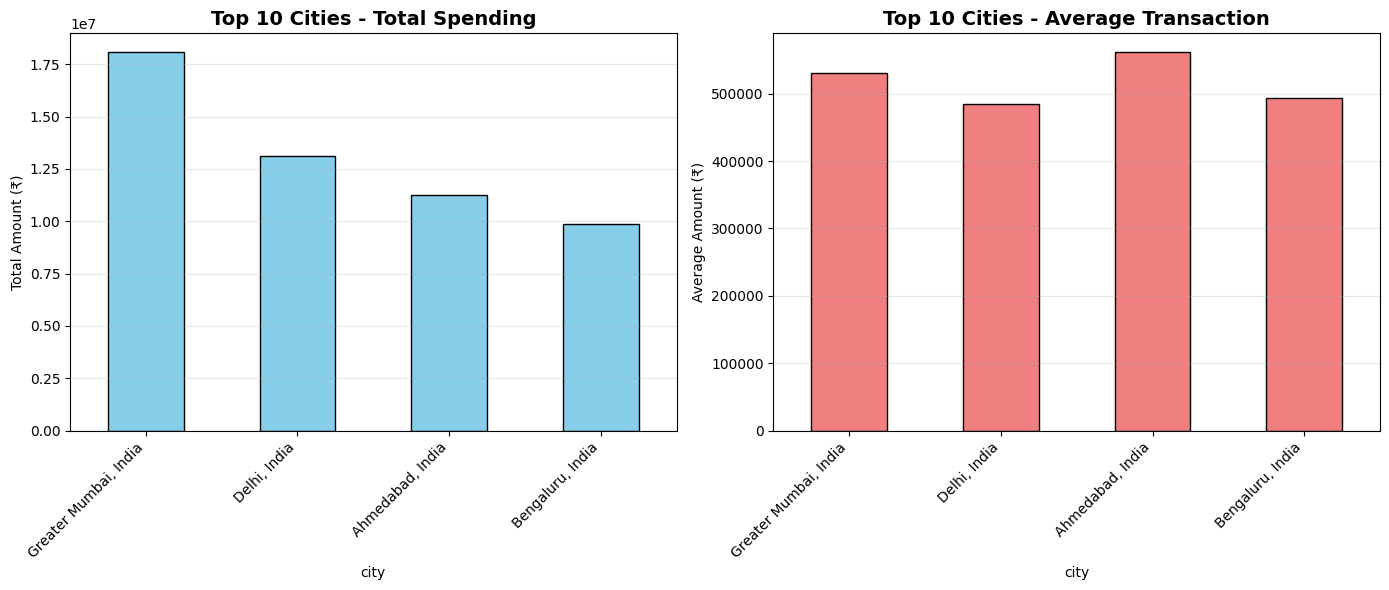


📅 Monthly Spending Statistics:
Average: ₹2,613,879.15
Maximum: ₹5,584,386.00
Minimum: ₹853,074.00
Total: ₹52,277,583.00


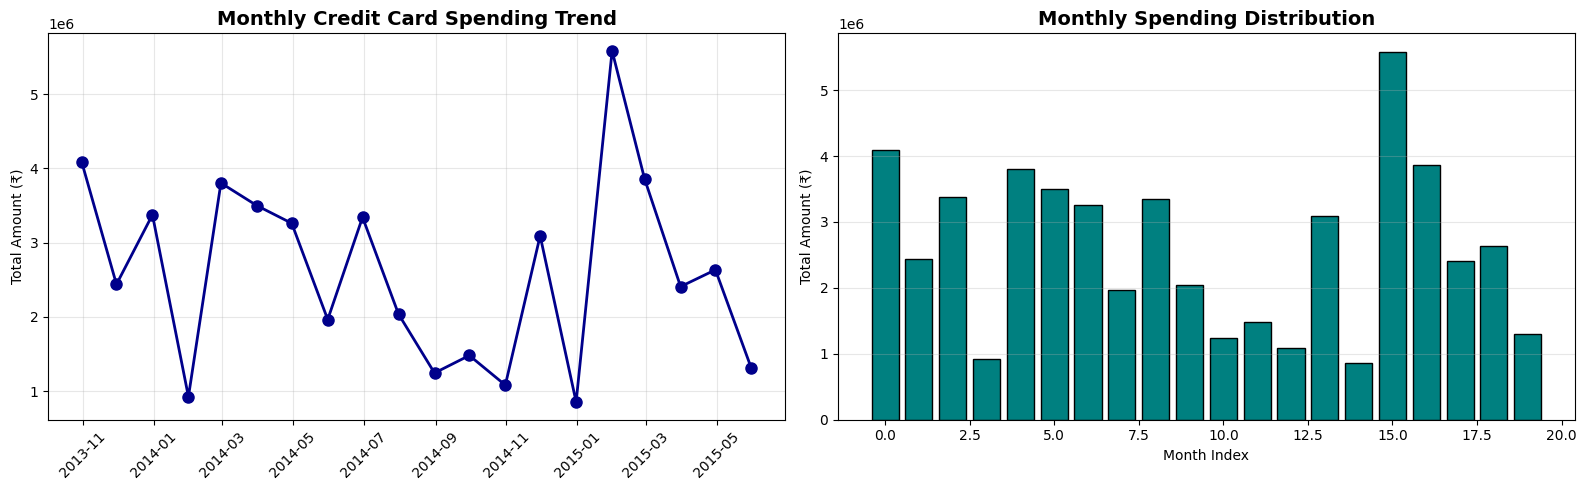


📊 Top Expense Categories:


,total,mean,count
card_type,,,
Platinum,18351549,556107.55,33
Gold,15111818,539707.79,28
Signature,10758767,467772.48,23
Silver,8055449,473849.94,17


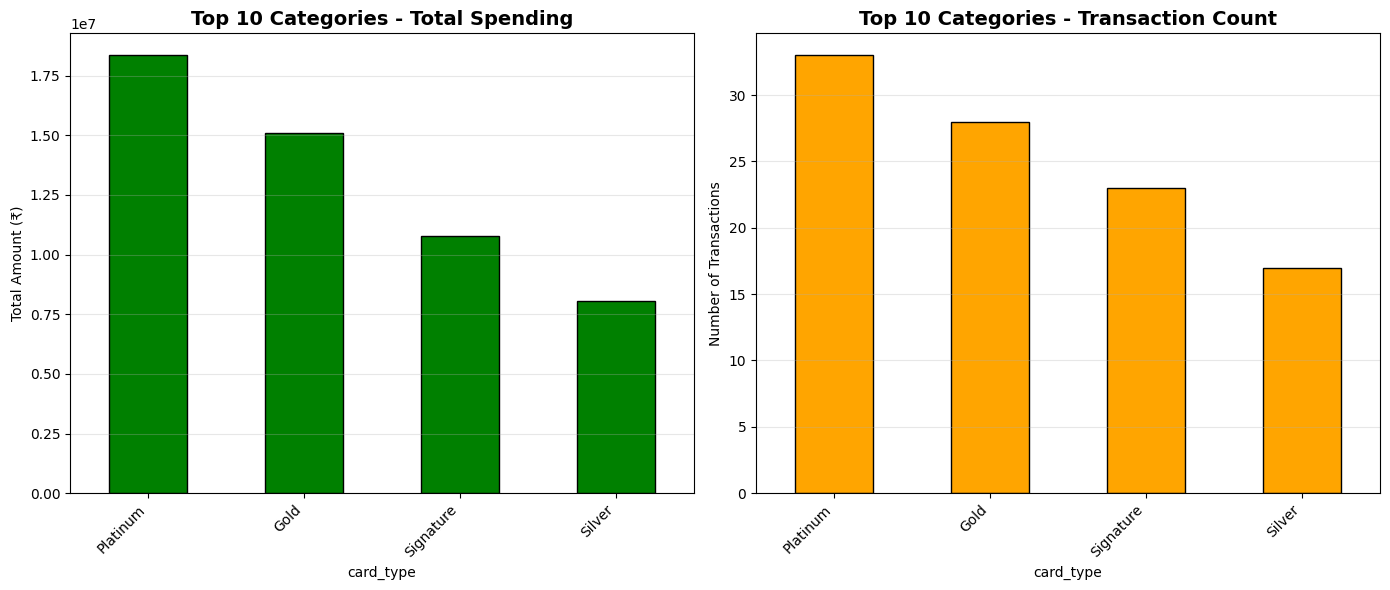


💳 Card Type Analysis:


,count,mean,median,sum,min,max
card_type,,,,,,
Platinum,33,556107.55,581882.0,18351549,32555,998077
Gold,28,539707.79,513374.0,15111818,19226,991685
Signature,23,467772.48,421878.0,10758767,123424,858729
Silver,17,473849.94,467014.0,8055449,100036,934205


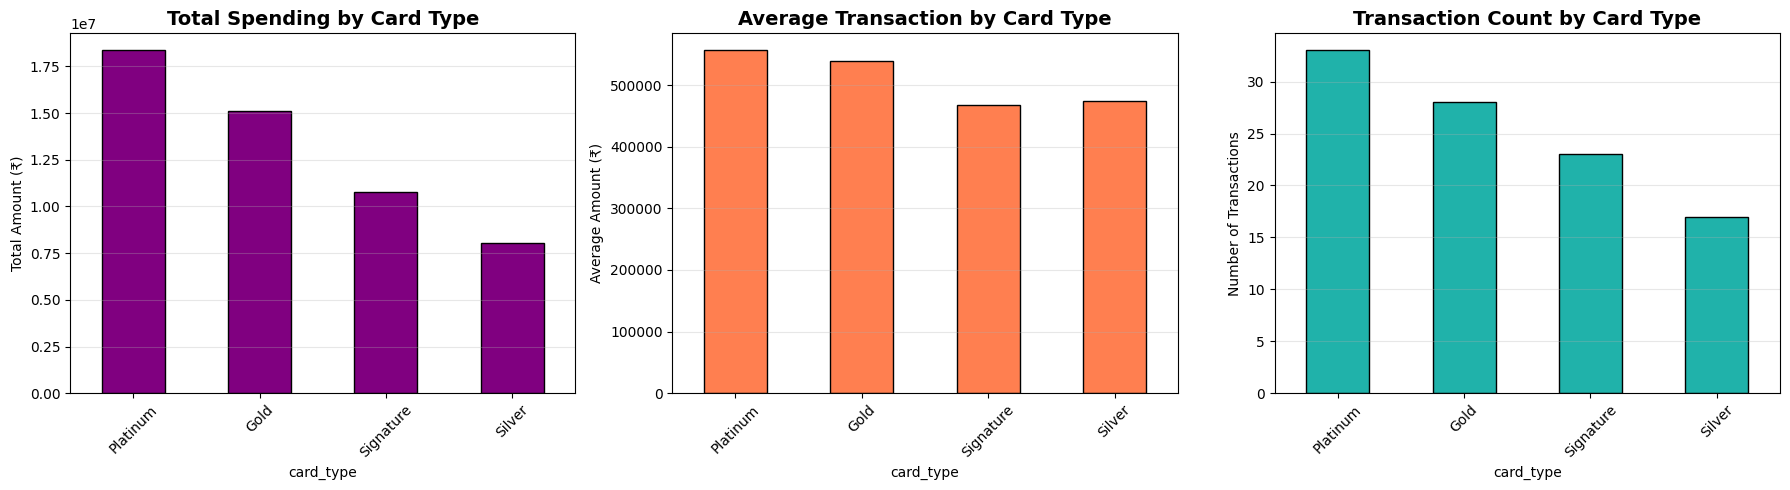


👤 Gender-Based Spending Analysis:


,total,mean,count
gender,,,
F,52277583,517599.83,101


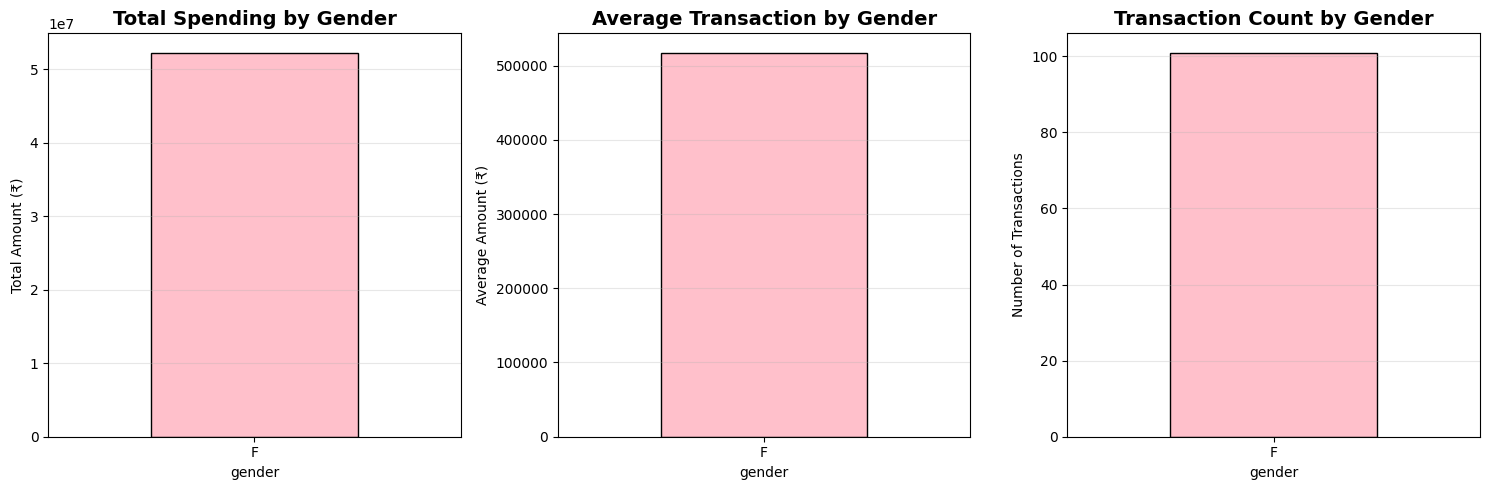


✅ All analyses completed successfully!


In [29]:
print("=" * 60)
print("EXECUTING DATA ANALYSIS")
print("=" * 60)

city_analysis = analyze_city_spending(df_clean, amount_col)

if date_col:
    monthly_analysis = analyze_monthly_trends(df_clean, date_col, amount_col)

expense_analysis = analyze_expense_categories(df_clean, amount_col)
card_analysis = analyze_card_types(df_clean, amount_col)
gender_analysis = analyze_gender_spending(df_clean, amount_col)

print("\n✅ All analyses completed successfully!")

# Summary Report

In [30]:
print("=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)

print(f"\n📊 KEY METRICS:")
print(f"💰 Total Spending: ₹{df_clean[amount_col].sum():,.2f}")
print(f"💵 Average Transaction Value: ₹{df_clean[amount_col].mean():,.2f}")
print(f"🔄 Total Transactions: {df_clean.shape[0]:,}")
print(f"📈 Median Transaction: ₹{df_clean[amount_col].median():,.2f}")
print(f"📉 Min Transaction: ₹{df_clean[amount_col].min():,.2f}")
print(f"📈 Max Transaction: ₹{df_clean[amount_col].max():,.2f}")

if 'city' in df_clean.columns:
    print(f"🏙️ Unique Cities: {df_clean['city'].nunique():,}")

if date_col:
    print(f"📅 Date Range: {df_clean[date_col].min()} → {df_clean[date_col].max()}")
    print(f"⏱️ Time Period: {(df_clean[date_col].max() - df_clean[date_col].min()).days} days")

ANALYSIS SUMMARY

📊 KEY METRICS:
💰 Total Spending: ₹52,277,583.00
💵 Average Transaction Value: ₹517,599.83
🔄 Total Transactions: 101
📈 Median Transaction: ₹525,977.00
📉 Min Transaction: ₹19,226.00
📈 Max Transaction: ₹998,077.00
🏙️ Unique Cities: 4
📅 Date Range: 2013-10-04 00:00:00 → 2015-05-13 00:00:00
⏱️ Time Period: 586 days


# Additional Visualization - Correlation Heatmap

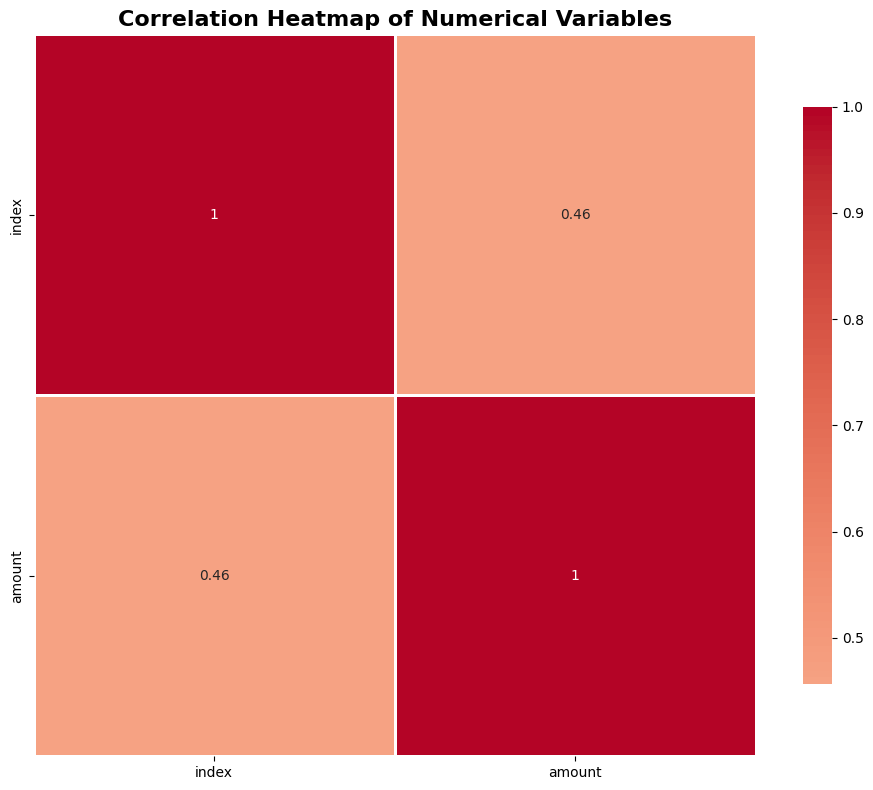

In [31]:
# Select numerical columns for correlation analysis
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df_clean[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title("Correlation Heatmap of Numerical Variables", fontweight="bold", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Not enough numerical columns for correlation heatmap")